In [41]:
# =================================================================================================
# Simulación del proceso de Difusion Wright-Fisher
# Autor: Rodolfo Escamilla Lara
# Descripción: Este script simula una trayectoria del modelo de Difusion Wright-Fisher con mutacion
# y sin mutacion mediante 2 Metodos, el metodo de Euler-Maruyama y el metodo de Milstein
# =================================================================================================

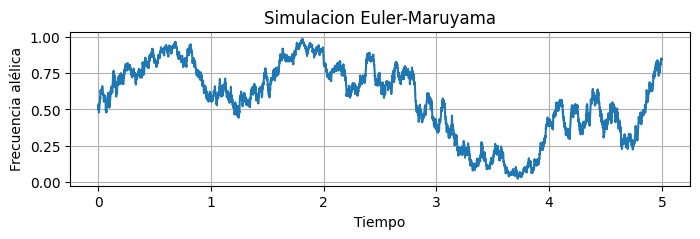

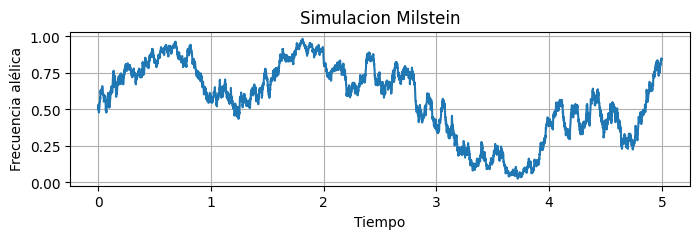

In [42]:
# importamos las librerias que usaremos para el script
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Aqui generamos las normales para ambas simulaciones
# ============================================================
T = 5      # Intervalo de tiempo por la que simularemos nuestro Wright-Fisher
dt = 0.001   # Partiremos de manera homogenea el intervalo (T) cada uno de tamaño dt
dB = np.random.normal(0, np.sqrt(dt), 5000)  # Para saber el numero de normales que debes al menos generar, es la siguiente.
                                            # T/dt = Numero de normales que debes al menos generar, como en este caso
                                            # Usamos timepo (T = 5) y partimos en intervalos de tamaño (dt=0.001) generamos 5,000 normales
                                            # (la minima). Dado el caso que cambien el tiempo (T) o tamaño intervalos (dt) se debe cambiar
                                            # la cantidad minima de normales que se deben generar. Que de acuerdo a lo anterior es (T/dt)

# ==========================================================================
# Metodo de Euler-Maruyama
# ==========================================================================


# ============================================================
# Parámetros de mutación Wright-Fisher
# ============================================================

num_pasos = int(T / dt) # Numero de intervalos que parten el tiempo T
N = int(1/dt) # Numero de la poblacion
gamma = 0.001   # Probabilidad de mutacion de un alelo del tipo (A2) hacia un alelo del tipo (A1)
alpha = 0.001   # Probabilidad de mutacion de un alelo de tipo (A1) hacia un alelo de tipo (A2)
delta = N*gamma      # Intensidad de mutacion de (A_2) hacia (A_1)
beta = N*alpha      # Intensidad de mutacion de (A_1) hacia (A_2)

# ==========================================================================
# Algoritmo para la simulacion de la difusion por metodo de Euler-Maruyama
# ==========================================================================

t = np.linspace(0, T, num_pasos+1)  # Aqui es la generacion de la particion del intervalo T
x = np.zeros(num_pasos+1)  # Generamos el vector x donde guardaremos los valores del Wright-Fisher
x[0] = 0.5     # La condcion incial

for i in range(num_pasos):

    drift = delta * (1 - x[i]) - beta * x[i]
    diffusion = np.sqrt(x[i] * (1 - x[i]))
    x[i+1] = x[i] + drift * dt + diffusion * dB[i]
    x[i+1] = min(1, max(0, x[i+1])) # Evitar salir de [0,1]

# ==========================================================================
# Plot de la difusion
# ==========================================================================

plt.figure(figsize=(8, 2))
plt.plot(t, x)
plt.title("Simulacion Euler-Maruyama")
plt.xlabel("Tiempo")
plt.ylabel("Frecuencia alélica")
plt.grid(True)
plt.savefig("euler_alpha_()_gamma_().png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

#=====================================================================================================#

# ==========================================================================
# Metodo de Milstein
# ==========================================================================


# ============================================================
# Parámetros de mutación Wright-Fisher
# ============================================================

num_pasos = int(T / dt) # Numero de intervalos que parten el tiempo T
N = int(1/dt) # Numero de la poblacion
gamma = 0.001   # probabilidad de mutacion de un alelo del tipo (A2) hacia un alelo del tipo (A1)
alpha = 0.001   # probabilidad de mutacion de un alelo de tipo (A1) hacia un alelo de tipo (A2)
delta = N*gamma      # Intensidad de mutacion de (A_2) hacia (A_1)
beta = N*alpha      # Intensidad de mutacion de (A_1) hacia (A_2)

# ==========================================================================
# Algoritmo para la simulacion de la difusion por metodo de Milstein
# ==========================================================================

t = np.linspace(0, T, num_pasos+1) # Aqui es la generacion de la particion del intervalo T
x = np.zeros(num_pasos+1) # Generamos el vector x donde guardaremos los valores del Wright-Fisher
x[0] = 0.5   # La condcion incial

for i in range(num_pasos):

    drift = delta * (1 - x[i]) - beta * x[i]
    diffusion = np.sqrt(x[i] * (1 - x[i]))
    x[i+1] = x[i] + drift * dt + diffusion * dB[i] + (1-2*x[i])/4*(dB[i]**2 - dt)
    x[i+1] = min(1, max(0, x[i+1]))  # Evitar salir de [0,1]


# ==========================================================================
# Plot de la difusion
# ==========================================================================

plt.figure(figsize=(8, 2))
plt.plot(t, x)
plt.title("Simulacion Milstein")
plt.xlabel("Tiempo")
plt.ylabel("Frecuencia alélica")
plt.grid(True)
plt.savefig("milstein_alpha_()_gamma_().png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

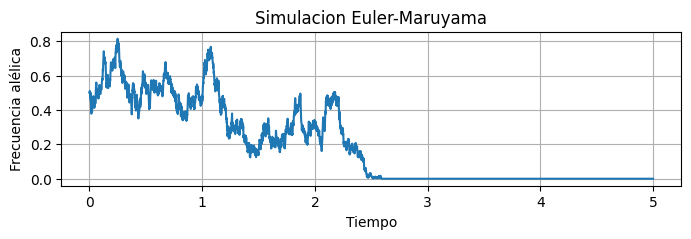

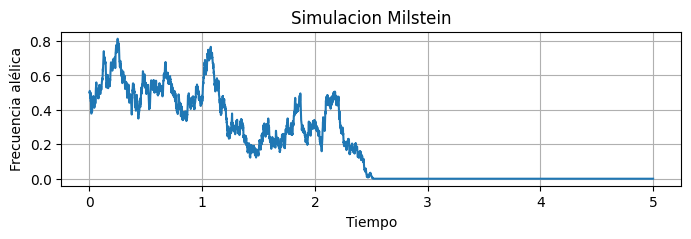

In [43]:
# =============================================================
# Caso sin mutacion
# =============================================================

# importamos las librerias que usaremos para el script
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================================
# Metodo de Euler-Maruyama
# ==========================================================================

# ============================================================
# Aqui generamos las normales para ambas simulaciones
# ============================================================

T = 5      # Intervalo de tiempo por la que simularemos nuestro Wright-Fisher
dt = 0.001   # Partiremos de manera homogenea el intervalo (T) cada uno de tamaño dt
dB = np.random.normal(0, np.sqrt(dt), 5000)  # Para saber el numero de normales que debes al menos generar, es la siguiente.
                                            # T/dt = Numero de normales que debes al menos generar, como en este caso
                                            # Usamos timepo (T = 5) y partimos en intervalos de tamaño (dt=0.001) generamos 5,000 normales
                                            # (la minima). Dado el caso que cambien el tiempo (T) o tamaño intervalos (dt) se debe cambiar
                                            # la cantidad minima de normales que se deben generar. Que de acuerdo a lo anterior es (T/dt)


# ============================================================
# Parámetros del Wright-Fisher sin mutacion
# ============================================================

num_pasos = int(T / dt)  # Numero de intervalos que parten el tiempo T
N = int(1/dt)  # Numero de la poblacion


# ==========================================================================
# Algoritmo para la simulacion de la difusion por metodo de Euler-Maruyama
# ==========================================================================

t = np.linspace(0, T, num_pasos+1) # Aqui es la generacion de la particion del intervalo T
x = np.zeros(num_pasos+1) # Generamos el vector x donde guardaremos los valores del Wright-Fisher
x[0] = 0.5   # La condcion incial

for i in range(num_pasos):
    if x[i] == 0:
        x[i+1] = 0
        continue
    else:
        if x[i] == 1:
            x[i+1] = 1
            continue
    diffusion = np.sqrt(x[i] * (1 - x[i]))
    x[i+1] = x[i] + diffusion * dB[i]
    x[i+1] = min(1, max(0, x[i+1]))  # Evitar salir de [0,1]

# ==========================================================================
# Plot de la difusion
# ==========================================================================

plt.figure(figsize=(8, 2))
plt.plot(t, x)
plt.title("Simulacion Euler-Maruyama")
plt.xlabel("Tiempo")
plt.ylabel("Frecuencia alélica")
plt.grid(True)
plt.savefig("euler.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

#=====================================================================================================#

# ==========================================================================
# Metodo de Milstein
# ==========================================================================

# ============================================================
# Parámetros del Wright-Fisher sin mutacion
# ============================================================

num_pasos = int(T / dt)  # Numero de intervalos que parten el tiempo T
N = int(1/dt)  # Numero de la poblacion

# ==========================================================================
# Algoritmo para la simulacion de la difusion por metodo de Euler-Maruyama
# ==========================================================================

t = np.linspace(0, T, num_pasos+1) # Aqui es la generacion de la particion del intervalo T
x = np.zeros(num_pasos+1) # Generamos el vector x donde guardaremos los valores del Wright-Fisher
x[0] = 0.5   # La condcion incial

for i in range(num_pasos):
    if x[i] == 0:
        x[i+1] = 0
        continue
    else:
        if x[i] == 1:
            x[i+1] = 1
            continue
    diffusion = np.sqrt(x[i] * (1 - x[i]))
    x[i+1] = x[i] + diffusion * dB[i] + (1-2*x[i])/4*(dB[i]**2 - dt)
    x[i+1] = min(1, max(0, x[i+1]))   # Evitar salir de [0,1]

# ==========================================================================
# Plot de la difusion
# ==========================================================================

plt.figure(figsize=(8, 2))
plt.plot(t, x)
plt.title("Simulacion Milstein")
plt.xlabel("Tiempo")
plt.ylabel("Frecuencia alélica")
plt.grid(True)
plt.savefig("milstein.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()
